In [26]:
import sys
from pathlib import Path
import pandas as pd

# Add project root to Python path
PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))


In [27]:
from common_utils.feature_engineering import add_engineered_features

df_fe = add_engineered_features(df)
df_fe.head()


,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges,bmi_category,age_bucket,family_size,is_high_risk
0,46.0,male,21.45,5.0,yes,southeast,Diabetes,None,Never,Blue collar,Premium,20460.307669,normal,middle_aged,6.0,0
1,25.0,female,25.38,2.0,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218,overweight,young,3.0,0
2,38.0,male,44.88,2.0,yes,southwest,None,High blood pressure,Occasionally,Blue collar,Premium,20204.476302,obese,adult,3.0,1
3,25.0,male,19.89,0.0,no,northwest,None,Diabetes,Rarely,White collar,Standard,11789.029843,normal,young,1.0,0
4,49.0,male,38.21,3.0,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,19268.309838,obese,middle_aged,4.0,1


In [28]:
df_fe[["bmi_category", "age_bucket", "family_size", "is_high_risk"]].value_counts()


bmi_category  age_bucket   family_size  is_high_risk
obese         adult        4.0          1               15351
                           3.0          0               15327
                                        1               15255
                           1.0          1               15255
              middle_aged  4.0          1               15232
                                                        ...  
overweight    adult        2.0          1                   4
              senior       1.0          1                   3
              young        2.0          1                   1
                           6.0          1                   1
                           5.0          1                   1
Name: count, Length: 144, dtype: int64

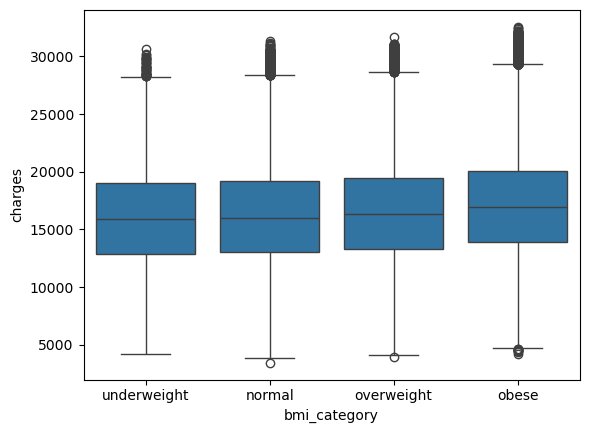

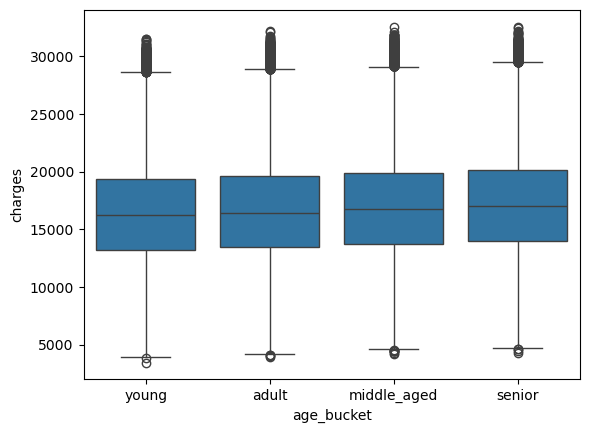

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="bmi_category", y="charges", data=df_fe)
plt.show()

sns.boxplot(x="age_bucket", y="charges", data=df_fe)
plt.show()


In [30]:
PROCESSED_PATH = (
    PROJECT_ROOT /
    "insurance_premium_prediction" /
    "data" /
    "processed" /
    "insurance_fe.parquet"
)

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df_fe.to_parquet(PROCESSED_PATH, index=False)

print(f"Feature-engineered data saved at: {PROCESSED_PATH}")


Feature-engineered data saved at: /Users/ranjanapatidar/Documents/Inttrvu/ai-ml-capstone/regression-models-lab/insurance_premium_prediction/data/processed/insurance_fe.parquet
